### Импорты

In [1]:
import geopandas as gpd
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

### Настройки

In [25]:
SCENARIO = 'scen_2'

In [26]:
# ---- пути к файлам ----
BUILDINGS_PATH = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\houses.gpkg'       # жилые здания
STOPS_PATH = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\stops.gpkg'           # остановочные пункты
ISOCHRONES_PATH  = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\isochrones_start.gpkg'     # 500-м изохроны
ROUTES_PATH = fr'X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\4_result\{SCENARIO}\routes.gpkg'   # маршруты




# ---- параметры ----
PROVISION_RATE   = 23.0        # м² жилой площади на 1 человека
LINE_ID_SEP      = ","         # разделитель id маршрутов в поле line_id остановок

### Загрузка данных

In [31]:
buildings  = gpd.read_file(BUILDINGS_PATH)
stops      = gpd.read_file(STOPS_PATH)
isochrones = gpd.read_file(ISOCHRONES_PATH)
routes     = gpd.read_file(ROUTES_PATH)

# Приведение к единой системе координат (берём CRS зданий)
target_crs = buildings.crs
stops      = stops.to_crs(target_crs)

print(f"Зданий:    {len(buildings)}")
print(f"Остановок: {len(stops)}")
print(f"Изохрон:   {len(isochrones)}")
print(f"Маршрутов: {len(routes)}")
print(f"CRS:       {target_crs}")

Зданий:    3155
Остановок: 690
Изохрон:   690
Маршрутов: 95
CRS:       EPSG:4326


In [32]:
isochrones

,group_index,value,area,total_pop,point_id,source_lon,source_lat,center,ya_stop_id,geometry
0,0,500.0,"536,252.6","4,761.0",stop__9884354,53.2,56.8,NaN,stop__9884354,"POLYGON ((53.1941 56.84406, 53.1977 56.84091, ..."
1,0,500.0,"500,412.8","2,763.0",stop__9884378,53.2,56.8,NaN,stop__9884378,"POLYGON ((53.19336 56.83974, 53.19643 56.83776..."
2,0,500.0,"417,812.1","1,575.0",stop__9884383,53.2,56.8,NaN,stop__9884383,"POLYGON ((53.17644 56.83143, 53.17841 56.83056..."
3,0,500.0,"430,162.5","1,206.0",stop__9884414,53.2,56.8,NaN,stop__9884414,"POLYGON ((53.17711 56.82762, 53.18093 56.82514..."
4,0,500.0,"545,037.7","4,317.0",stop__9884444,53.2,56.8,NaN,stop__9884444,"POLYGON ((53.17123 56.8167, 53.17121 56.81634,..."
...,...,...,...,...,...,...,...,...,...,...
685,0,500.0,"540,649.2","2,754.0",stop__9884380,53.3,56.9,NaN,stop__9884380,"POLYGON ((53.28454 56.86028, 53.28456 56.85992..."
686,0,500.0,"570,183.5","7,902.0",3767017460,53.1,56.8,NaN,3767017460,"POLYGON ((53.12477 56.82936, 53.12546 56.82686..."
687,0,500.0,"517,712.0","8,339.0",3764629460,53.3,56.9,NaN,3764629460,"POLYGON ((53.28404 56.85167, 53.28391 56.85133..."
688,0,500.0,"475,874.5","2,901.0",stop__1,53.3,56.8,"[53.288343424242385, 56.83746618304799]",stop__1,"POLYGON ((53.28175 56.83473, 53.28289 56.83391..."


### Настройки визуализации

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Шрифт с поддержкой кириллицы (раскомментируйте нужный)
# plt.rcParams["font.family"] = "DejaVu Sans"
# plt.rcParams["font.family"] = "Arial"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

TOP_N = 20  # сколько маршрутов показывать на графиках

### Расчёт населения по зданиям

In [30]:
# Фильтрация: оставляем только здания с площадью > 0
buildings = buildings[buildings["res_area"].fillna(0) > 0].copy()

# Уникальный id здания (нужен для исключения двойного счёта)
buildings["building_id"] = range(len(buildings))

# Оценка числа жителей
buildings["population"] = buildings["res_area"] / PROVISION_RATE

total_population = buildings["population"].sum()

print(f"Жилых зданий (res_area > 0): {len(buildings)}")
print(f"Суммарная жилая площадь:     {buildings['res_area'].sum():,.0f} м²")
print(f"Оценка населения города:     {total_population:,.0f} чел.")

Жилых зданий (res_area > 0): 3086
Суммарная жилая площадь:     14,778,624 м²
Оценка населения города:     642,549 чел.


### Пространственное соединение: здания ↔ изохроны

In [42]:
# Для каждого здания определяем, в изохрону каких остановок оно попадает.
# predicate='intersects' — здание считается обслуживаемым,
# если хотя бы частично пересекается с изохроной.
# Альтернатива: создать центроиды зданий и использовать 'within'.

bld_iso = gpd.sjoin(
    buildings[["building_id", "population", "geometry"]],
    isochrones[["ya_stop_id", "geometry"]],
    how="inner",
    predicate="intersects",
)

# Убираем возможные дубли (одно здание дважды в одной изохроне)
bld_iso = bld_iso.drop_duplicates(subset=["building_id", "ya_stop_id"])

print(f"Пар «здание — остановка»: {len(bld_iso)}")
print(f"Уникальных зданий в зоне доступности хотя бы одной остановки: "
      f"{bld_iso['building_id'].nunique()}")

Пар «здание — остановка»: 13785
Уникальных зданий в зоне доступности хотя бы одной остановки: 2695


In [43]:
bld_iso

,building_id,population,geometry,index_right,ya_stop_id
0,0,4.9,POINT (53.22528 56.79773),191,stop__9884531
0,0,4.9,POINT (53.22528 56.79773),467,2180000492
0,0,4.9,POINT (53.22528 56.79773),461,stop__9884542
1,1,4.9,POINT (53.22528 56.79773),191,stop__9884531
1,1,4.9,POINT (53.22528 56.79773),467,2180000492
...,...,...,...,...,...
3022,2953,199.3,POINT (53.28877 56.8609),681,1543164637
3022,2953,199.3,POINT (53.28877 56.8609),685,stop__9884380
3022,2953,199.3,POINT (53.28877 56.8609),338,stop__9884082
3022,2953,199.3,POINT (53.28877 56.8609),327,stop__9884083


### Разбор связей «остановка → маршруты»

In [44]:
# Поле line_id в остановках содержит id нескольких маршрутов через разделитель.
# Разворачиваем в длинный формат: одна строка = одна пара (остановка, маршрут).

stops_routes = stops[["ya_stop_id", "ya_line_id"]].copy()
stops_routes["ya_line_id"] = (
    stops_routes["ya_line_id"]
    .astype(str)
    .str.split(LINE_ID_SEP)
)
stops_routes = stops_routes.explode("ya_line_id")
stops_routes["ya_line_id"] = stops_routes["ya_line_id"].str.strip()

# Убираем пустые значения, если есть
stops_routes = stops_routes[stops_routes["ya_line_id"].astype(bool)]

print(f"Пар «остановка — маршрут»: {len(stops_routes)}")
print(f"Уникальных маршрутов в остановках: {stops_routes['ya_line_id'].nunique()}")

Пар «остановка — маршрут»: 2437
Уникальных маршрутов в остановках: 50


### Связь зданий с маршрутами

In [45]:
# Соединяем:
#   здание ↔ остановка (из spatial join)  +  остановка ↔ маршрут

bld_routes = bld_iso[["building_id", "population", "ya_stop_id"]].merge(
    stops_routes,
    on="ya_stop_id",
    how="inner",
)

# Ключевой шаг: убираем дубли «здание — маршрут»,
# чтобы каждое здание учитывалось для маршрута только один раз,
# даже если оно попадает в изохроны нескольких остановок одного маршрута.

bld_routes_unique = bld_routes.drop_duplicates(subset=["building_id", "ya_line_id"])

print(f"Уникальных пар «здание — маршрут»: {len(bld_routes_unique)}")

Уникальных пар «здание — маршрут»: 22743


### Агрегация: статистика по каждому маршруту

In [46]:
# --- население и здания по маршруту ---
route_stats = (
    bld_routes_unique
    .groupby("ya_line_id")
    .agg(
        population_served=("population", "sum"),
        buildings_served=("building_id", "nunique"),
    )
    .reset_index()
)

# --- количество остановок по маршруту ---
stops_per_route = (
    stops_routes
    .groupby("ya_line_id")["ya_stop_id"]
    .nunique()
    .reset_index()
    .rename(columns={"ya_stop_id": "stops_count"})
)
route_stats = route_stats.merge(stops_per_route, on="ya_line_id", how="left")

# --- название маршрута ---
routes["ya_line_id"] = routes["ya_line_id"].astype(str).str.strip()
route_stats = route_stats.merge(
    routes[["ya_line_id", "route_name_with_vhc_prefix"]].drop_duplicates(),
    on="ya_line_id",
    how="left",
)

# --- процент от населения города ---
route_stats["pct_of_city"] = (
    route_stats["population_served"] / total_population * 100
)

# --- округление ---
route_stats["population_served"] = route_stats["population_served"].round(0).astype(int)
route_stats["pct_of_city"] = route_stats["pct_of_city"].round(2)

# --- сортировка ---
route_stats = route_stats.sort_values("population_served", ascending=False).reset_index(drop=True)

# --- порядок столбцов ---
route_stats = route_stats[[
    "ya_line_id",
    "route_name_with_vhc_prefix",
    "stops_count",
    "buildings_served",
    "population_served",
    "pct_of_city",
]]

route_stats

,ya_line_id,route_name_with_vhc_prefix,stops_count,buildings_served,population_served,pct_of_city
0,2161483929,minibus_18,71,902,190072,31.9
1,2161483925,trolleybus_14,67,815,168252,28.2
2,2161483942,bus_36,81,819,166416,27.9
3,2161483913,bus_79,62,823,163443,27.4
4,2161483957,bus_29,54,806,163421,27.4
5,2161483988,bus_26,67,803,162676,27.3
6,6077430759,trolleybus_10д,81,730,159666,26.8
7,2161483970,minibus_52,39,712,153680,25.8
8,2161483989,bus_27,79,753,145388,24.4
9,2161483903,trolleybus_10,65,629,136296,22.9


In [47]:
vhc_stats

NameError: name 'vhc_stats' is not defined

### Агрегация по типам транспорта (ya_vhc_type)

In [48]:
# Подтягиваем тип транспорта из слоя маршрутов
routes["ya_line_id"] = routes["ya_line_id"].astype(str).str.strip()

bld_routes_typed = bld_routes_unique.merge(
    routes[["ya_line_id", "ya_vhc_type"]].drop_duplicates(),
    on="ya_line_id",
    how="left",
)

# ---- Количество маршрутов по типу — считаем ОТДЕЛЬНО,
#      без дедупликации зданий, чтобы не потерять line_id ----
routes_by_type = (
    bld_routes_typed[["ya_line_id", "ya_vhc_type"]]
    .drop_duplicates()                          # уникальные пары маршрут-тип
    .groupby("ya_vhc_type")["ya_line_id"]
    .nunique()
    .reset_index()
    .rename(columns={"ya_line_id": "routes_count"})
)

# ---- Население и здания по типу — здесь дедупликация корректна ----
pop_by_type = (
    bld_routes_typed
    .drop_duplicates(subset=["building_id", "ya_vhc_type"])
    .groupby("ya_vhc_type")
    .agg(
        buildings_served=("building_id", "nunique"),
        population_served=("population", "sum"),
    )
    .reset_index()
)

# ---- Соединяем ----
vhc_stats = pop_by_type.merge(routes_by_type, on="ya_vhc_type", how="left")

vhc_stats["pct_of_city"] = (
    vhc_stats["population_served"] / total_population * 100
)
vhc_stats["population_served"] = vhc_stats["population_served"].round(0).astype(int)
vhc_stats["pct_of_city"] = vhc_stats["pct_of_city"].round(2)

vhc_stats = vhc_stats.sort_values("population_served", ascending=False).reset_index(drop=True)

# Порядок столбцов
vhc_stats = vhc_stats[[
    "ya_vhc_type",
    "routes_count",
    "buildings_served",
    "population_served",
    "pct_of_city",
]]

# ---- Уникальный охват (без двойного счёта между типами) ----
all_served = bld_routes_typed.drop_duplicates(subset=["building_id"])
total_served_all_types = all_served["population"].sum()

print("=" * 70)
print("ОХВАТ НАСЕЛЕНИЯ ПО ТИПАМ ТРАНСПОРТА")
print("=" * 70)
print(f"Население города (оценка): {total_population:,.0f} чел.")
print(f"Всего обслужено (уник.):   {total_served_all_types:,.0f} чел. "
      f"({total_served_all_types / total_population * 100:.1f}%)")
print()

display(
    vhc_stats
    .style
    .format({
        "population_served": "{:,}",
        "pct_of_city": "{:.2f}%",
        "routes_count": "{:,}",
        "buildings_served": "{:,}",
    })
    .set_caption("Обслуживаемое население по типам транспорта")
    .bar(subset=["pct_of_city"], color="#5fba7d", vmin=0)
)

ОХВАТ НАСЕЛЕНИЯ ПО ТИПАМ ТРАНСПОРТА
Население города (оценка): 596,349 чел.
Всего обслужено (уник.):   535,605 чел. (89.8%)



,ya_vhc_type,routes_count,buildings_served,population_served,pct_of_city
0,bus,27,"2,392","481,329",80.71%
1,trolleybus,8,"1,792","358,878",60.18%
2,minibus,4,"1,675","331,390",55.57%
3,tramway,11,"1,188","211,776",35.51%


### Визуализация по типам транспорта

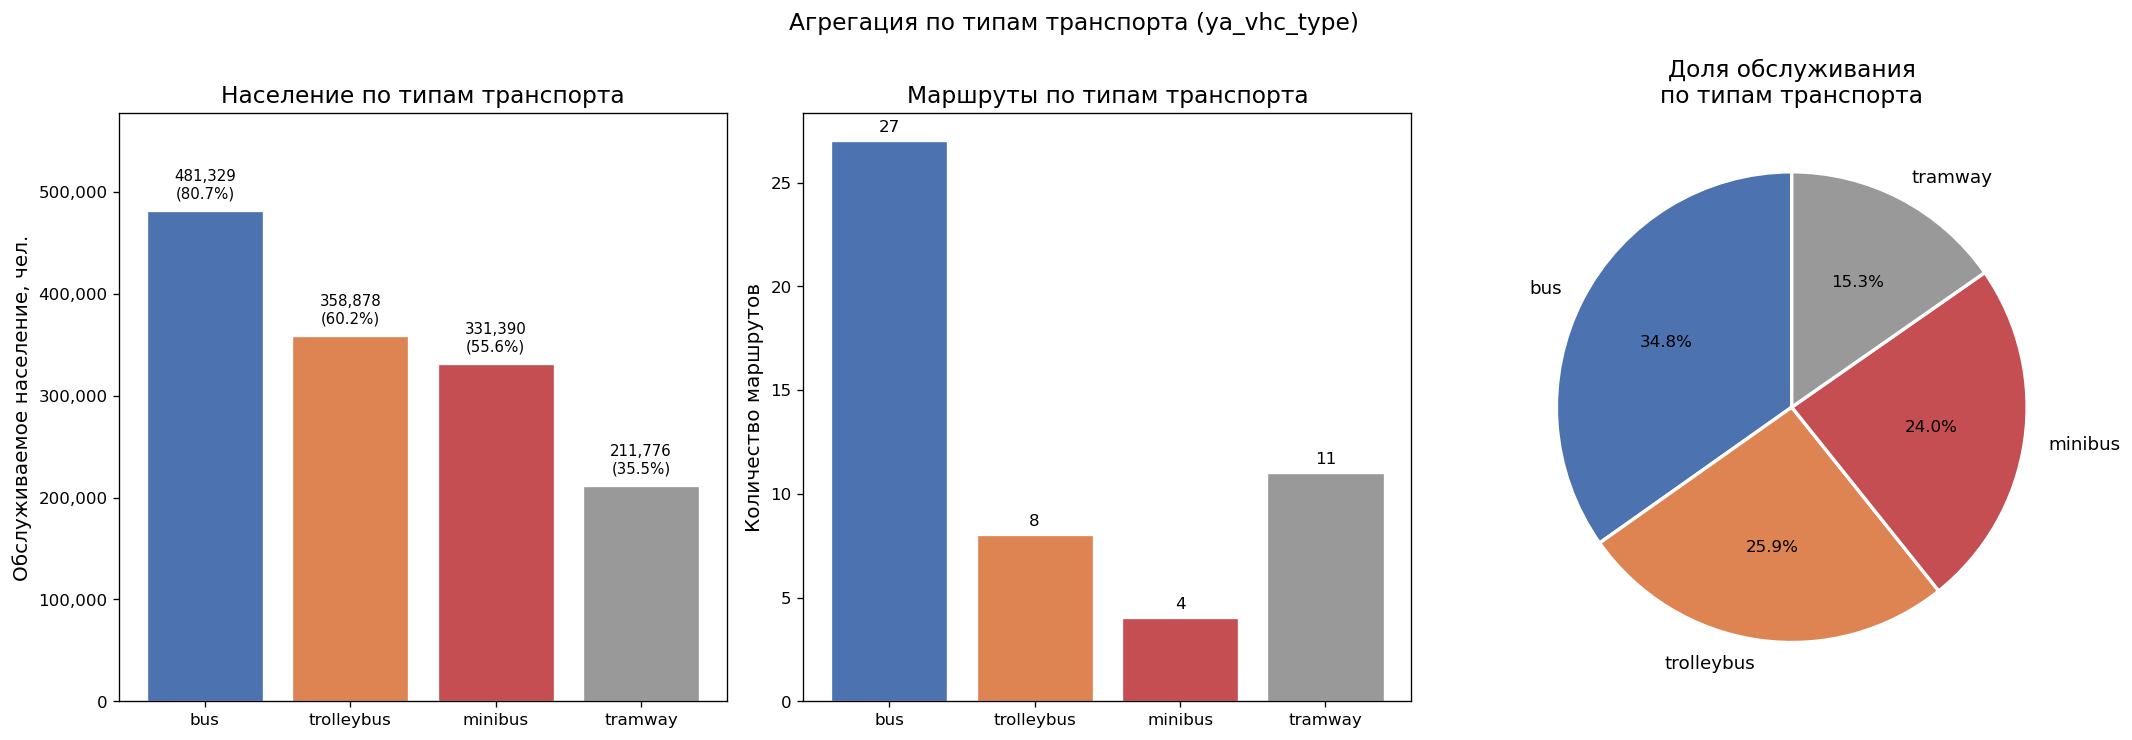

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---- 1. Столбчатая: население по типам ----
ax1 = axes[0]
colors_map = {
    "bus":        "#4C72B0",
    "trolleybus": "#DD8452",
    "tram":       "#55A868",
    "minibus":    "#C44E52",
    "metro":      "#8172B3",
}
bar_colors = [colors_map.get(v, "#999999") for v in vhc_stats["ya_vhc_type"]]

bars = ax1.bar(
    vhc_stats["ya_vhc_type"],
    vhc_stats["population_served"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
)
for bar, val, pct in zip(bars, vhc_stats["population_served"], vhc_stats["pct_of_city"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + vhc_stats["population_served"].max() * 0.02,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9,
    )
ax1.set_ylabel("Обслуживаемое население, чел.")
ax1.set_title("Население по типам транспорта")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.set_ylim(0, vhc_stats["population_served"].max() * 1.20)

# ---- 2. Столбчатая: количество маршрутов по типам ----
ax2 = axes[1]
bars2 = ax2.bar(
    vhc_stats["ya_vhc_type"],
    vhc_stats["routes_count"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
)
for bar, val in zip(bars2, vhc_stats["routes_count"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val}",
        ha="center", va="bottom", fontsize=10,
    )
ax2.set_ylabel("Количество маршрутов")
ax2.set_title("Маршруты по типам транспорта")

# ---- 3. Круговая: доля населения по типам ----
ax3 = axes[2]
wedges, texts, autotexts = ax3.pie(
    vhc_stats["population_served"],
    labels=vhc_stats["ya_vhc_type"],
    autopct=lambda p: f"{p:.1f}%",
    colors=bar_colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
for t in autotexts:
    t.set_fontsize(10)
ax3.set_title("Доля обслуживания\nпо типам транспорта")

plt.suptitle("Агрегация по типам транспорта (ya_vhc_type)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Пакетная выгрузка изохрон для ВСЕХ маршрутов

In [53]:
import os

OUTPUT_DIR = r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\routes"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_route_ids = route_stats["ya_line_id"].unique()
all_dissolved = []

for lid in all_route_ids:
    # Остановки маршрута
    r_stops = stops_routes.loc[
        stops_routes["ya_line_id"] == lid, "ya_stop_id"
    ].unique()

    # Изохроны этих остановок
    iso_r = isochrones[isochrones["ya_stop_id"].isin(r_stops)].copy()
    if len(iso_r) == 0:
        continue

    # Dissolve
    iso_r["dissolve_key"] = 1
    dissolved = iso_r.dissolve(by="dissolve_key").reset_index(drop=True)

    # Атрибуты
    r_name = routes.loc[routes["ya_line_id"] == lid, "route_name_with_vhc_prefix"]
    dissolved["ya_line_id"]     = lid
    dissolved["route_name_with_vhc_prefix"]  = r_name.values[0] if len(r_name) > 0 else None
    dissolved["stops_count"] = len(r_stops)

    if dissolved.crs and dissolved.crs.is_projected:
        dissolved["area_km2"] = (dissolved.geometry.area / 1e6).round(3)

    all_dissolved.append(dissolved)

# Объединяем всё в один GeoDataFrame
all_dissolved_gdf = pd.concat(all_dissolved, ignore_index=True)

keep = ["ya_line_id", "route_name_with_vhc_prefix", "stops_count", "geometry"]
if "area_km2" in all_dissolved_gdf.columns:
    keep.insert(-1, "area_km2")
all_dissolved_gdf = gpd.GeoDataFrame(all_dissolved_gdf[keep], crs=target_crs)

# Один файл со всеми маршрутами
OUTPUT_ALL = "isochrones_all_routes.gpkg"
all_dissolved_gdf.to_file(OUTPUT_DIR + '/' + OUTPUT_ALL, driver="GPKG")

print(f"Маршрутов обработано: {len(all_dissolved_gdf)}")
print(f"Сохранено:            {OUTPUT_ALL}")

Маршрутов обработано: 50
Сохранено:            isochrones_all_routes.gpkg


### Полная таблица + сводка

In [50]:
print("=" * 80)
print("РЕЗУЛЬТАТЫ: ОБСЛУЖИВАНИЕ МАРШРУТАМИ")
print("=" * 80)
print(f"Население города (оценка):  {total_population:,.0f} чел.")
print(f"Норма обеспеченности:       {PROVISION_RATE} м²/чел.")
print(f"Всего маршрутов:            {len(route_stats)}")
print()

# --- население, обслуживаемое хотя бы одним маршрутом ---
all_served_buildings = bld_routes_unique["building_id"].unique()
total_served_pop = buildings.loc[
    buildings["building_id"].isin(all_served_buildings), "population"
].sum()
print(f"Население в зоне доступности хотя бы одного маршрута: "
      f"{total_served_pop:,.0f} чел. "
      f"({total_served_pop / total_population * 100:.1f}%)")
print()

# --- таблица ---
display(
    route_stats
    .style
    .format({
        "population_served": "{:,}",
        "pct_of_city":       "{:.2f}%",
    })
    .set_caption("Население, обслуживаемое каждым маршрутом")
    .bar(subset=["pct_of_city"], color="#5fba7d", vmin=0)
)

РЕЗУЛЬТАТЫ: ОБСЛУЖИВАНИЕ МАРШРУТАМИ
Население города (оценка):  596,349 чел.
Норма обеспеченности:       23.0 м²/чел.
Всего маршрутов:            50

Население в зоне доступности хотя бы одного маршрута: 535,605 чел. (89.8%)



,ya_line_id,route_name_with_vhc_prefix,stops_count,buildings_served,population_served,pct_of_city
0,2161483929,minibus_18,71,902,"190,072",31.87%
1,2161483925,trolleybus_14,67,815,"168,252",28.21%
2,2161483942,bus_36,81,819,"166,416",27.91%
3,2161483913,bus_79,62,823,"163,443",27.41%
4,2161483957,bus_29,54,806,"163,421",27.40%
5,2161483988,bus_26,67,803,"162,676",27.28%
6,6077430759,trolleybus_10д,81,730,"159,666",26.77%
7,2161483970,minibus_52,39,712,"153,680",25.77%
8,2161483989,bus_27,79,753,"145,388",24.38%
9,2161483903,trolleybus_10,65,629,"136,296",22.86%


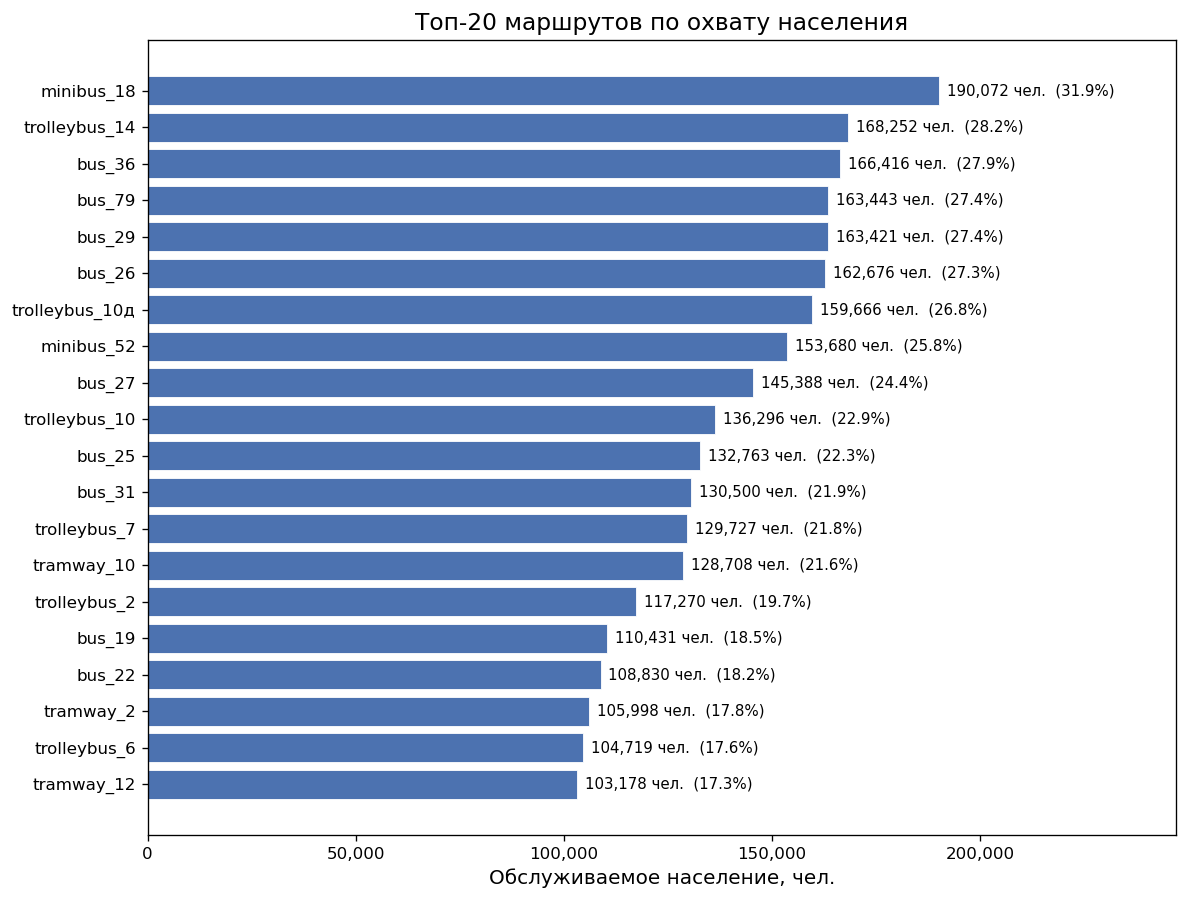

In [51]:
# ============================================================
# ЯЧЕЙКА 9.2 — Горизонтальная столбчатая: топ маршрутов по населению
# ============================================================

top = route_stats.head(TOP_N).copy()
top["label"] = top["route_name_with_vhc_prefix"].fillna(top["ya_line_id"])

fig, ax = plt.subplots(figsize=(10, max(6, TOP_N * 0.38)))

bars = ax.barh(
    y=top["label"][::-1],
    width=top["population_served"][::-1],
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
)

# Подписи значений на столбцах
for bar, val, pct in zip(
    bars,
    top["population_served"][::-1],
    top["pct_of_city"][::-1],
):
    ax.text(
        bar.get_width() + top["population_served"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,} чел.  ({pct:.1f}%)",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Обслуживаемое население, чел.")
ax.set_title(f"Топ-{TOP_N} маршрутов по охвату населения")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(0, top["population_served"].max() * 1.30)

plt.tight_layout()
plt.show()

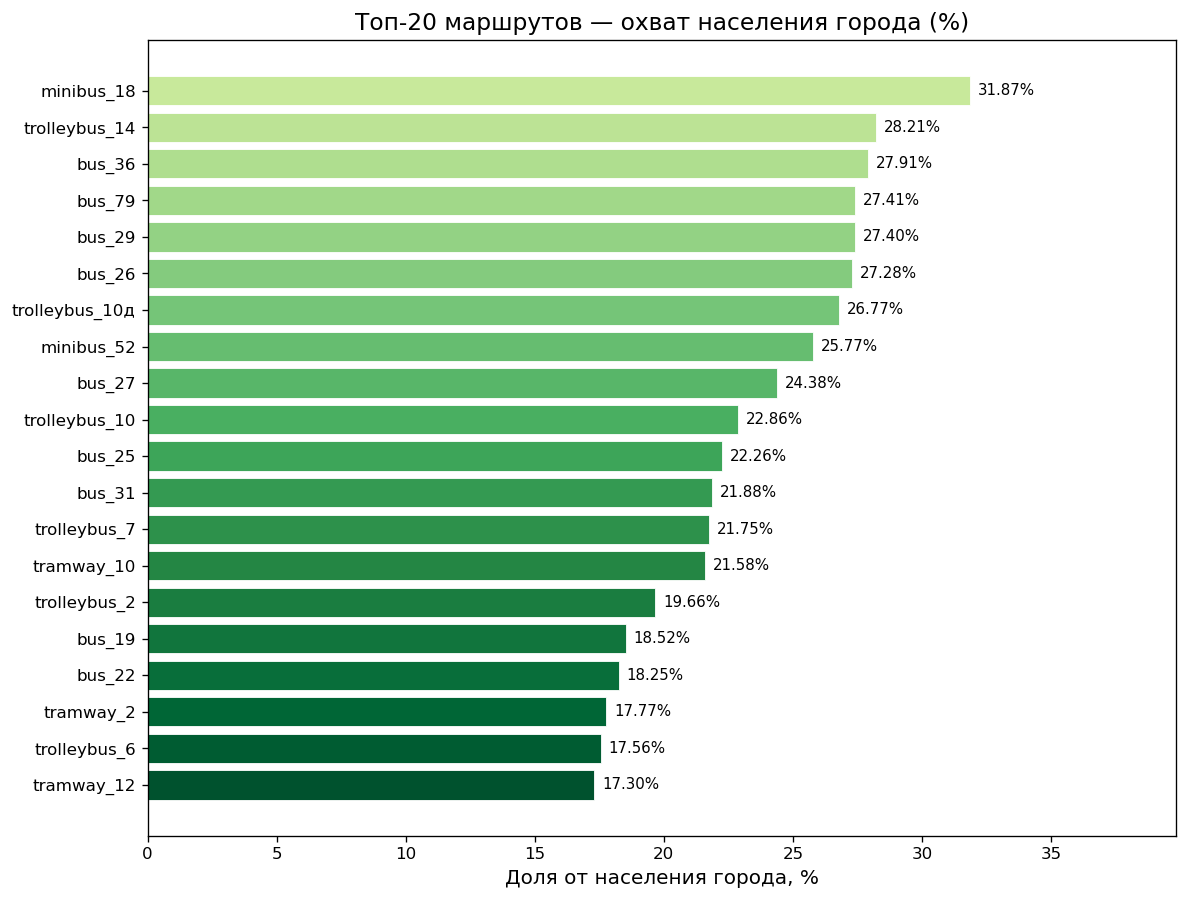

In [52]:
# ============================================================
# ЯЧЕЙКА 9.3 — Процент населения города по маршрутам (топ)
# ============================================================

fig, ax = plt.subplots(figsize=(10, max(6, TOP_N * 0.38)))

colors = plt.cm.YlGn(
    np.linspace(0.3, 0.95, TOP_N)
)[::-1]

bars = ax.barh(
    y=top["label"][::-1],
    width=top["pct_of_city"][::-1],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)

for bar, pct in zip(bars, top["pct_of_city"][::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Доля от населения города, %")
ax.set_title(f"Топ-{TOP_N} маршрутов — охват населения города (%)")
ax.set_xlim(0, top["pct_of_city"].max() * 1.25)

plt.tight_layout()
plt.show()

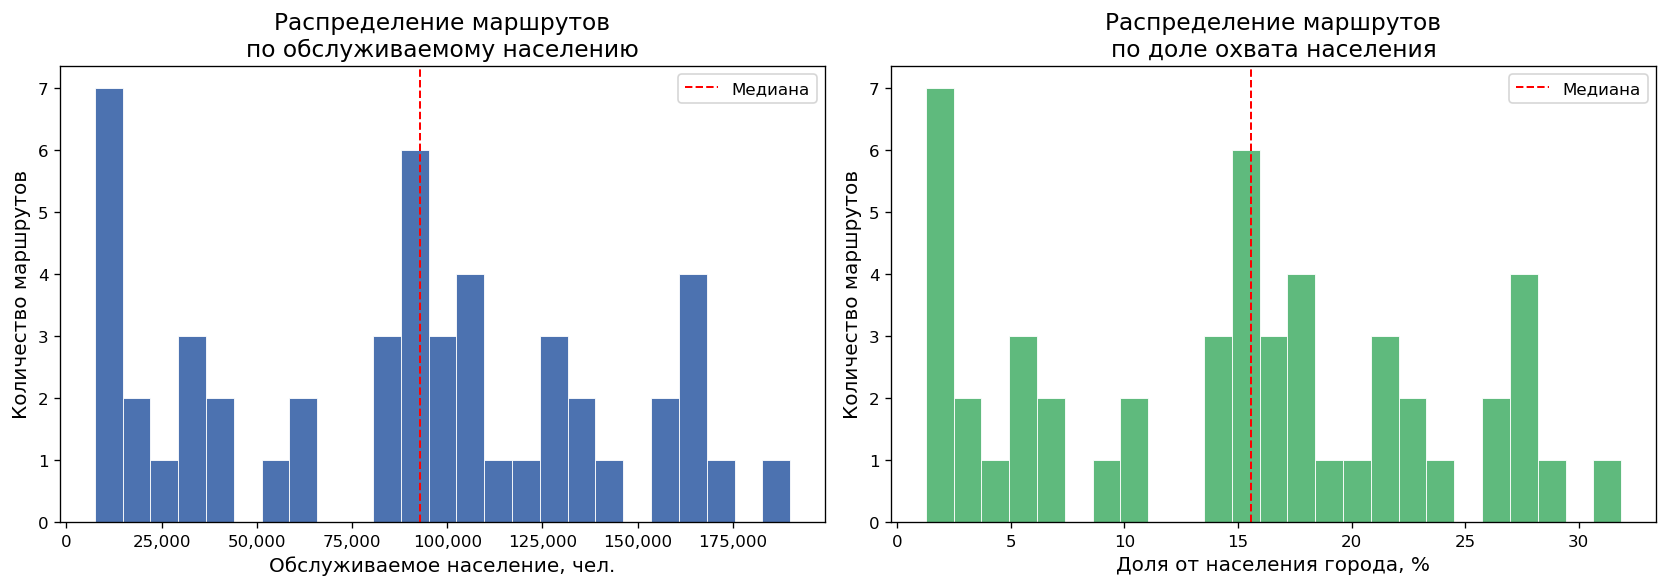

In [53]:
# ============================================================
# ЯЧЕЙКА 9.4 — Распределение маршрутов по охвату населения (гистограмма)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- гистограмма: абсолютные значения ---
ax1 = axes[0]
ax1.hist(
    route_stats["population_served"],
    bins=25,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
)
ax1.set_xlabel("Обслуживаемое население, чел.")
ax1.set_ylabel("Количество маршрутов")
ax1.set_title("Распределение маршрутов\nпо обслуживаемому населению")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.axvline(
    route_stats["population_served"].median(),
    color="red", linestyle="--", linewidth=1.2, label="Медиана",
)
ax1.legend()

# --- гистограмма: процент ---
ax2 = axes[1]
ax2.hist(
    route_stats["pct_of_city"],
    bins=25,
    color="#5fba7d",
    edgecolor="white",
    linewidth=0.5,
)
ax2.set_xlabel("Доля от населения города, %")
ax2.set_ylabel("Количество маршрутов")
ax2.set_title("Распределение маршрутов\nпо доле охвата населения")
ax2.axvline(
    route_stats["pct_of_city"].median(),
    color="red", linestyle="--", linewidth=1.2, label="Медиана",
)
ax2.legend()

plt.tight_layout()
plt.show()

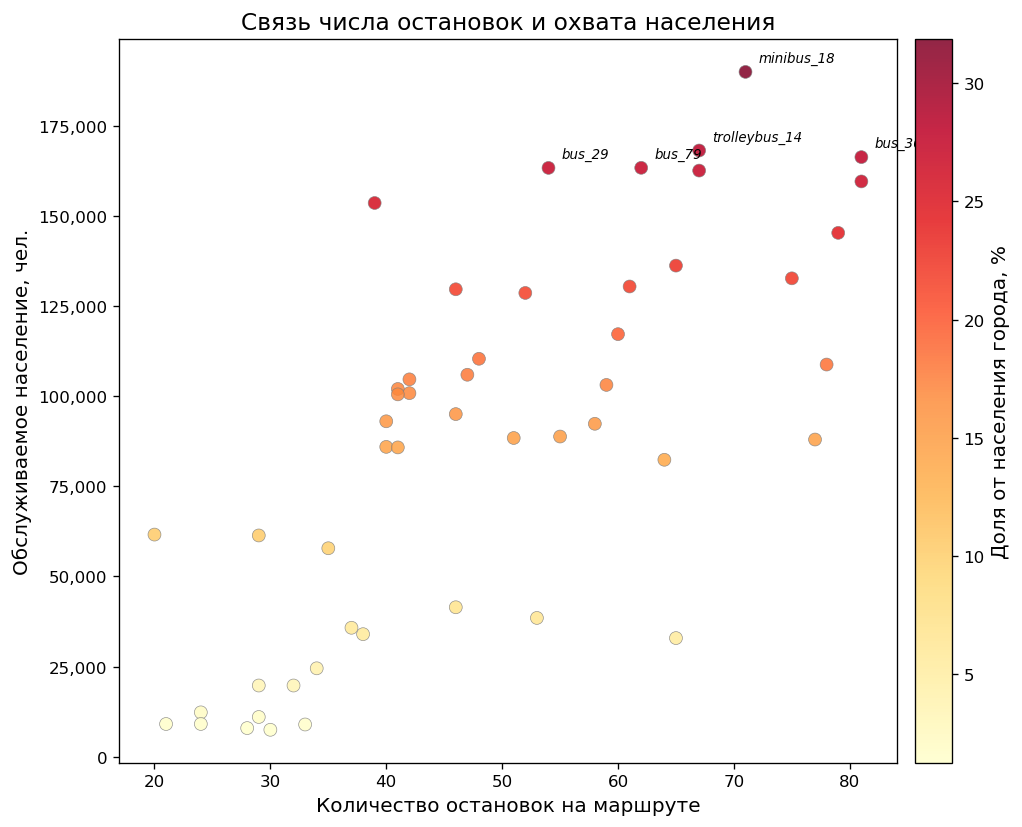

In [54]:
# ============================================================
# ЯЧЕЙКА 9.5 — Диаграмма: остановки vs население
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    route_stats["stops_count"],
    route_stats["population_served"],
    c=route_stats["pct_of_city"],
    cmap="YlOrRd",
    s=60,
    edgecolors="grey",
    linewidth=0.4,
    alpha=0.85,
)

# Подписи для топ-5
for _, row in route_stats.head(5).iterrows():
    label = row["route_name_with_vhc_prefix"] if pd.notna(row["route_name_with_vhc_prefix"]) else row["ya_line_id"]
    ax.annotate(
        label,
        (row["stops_count"], row["population_served"]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=8,
        fontstyle="italic",
    )

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Доля от населения города, %")

ax.set_xlabel("Количество остановок на маршруте")
ax.set_ylabel("Обслуживаемое население, чел.")
ax.set_title("Связь числа остановок и охвата населения")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

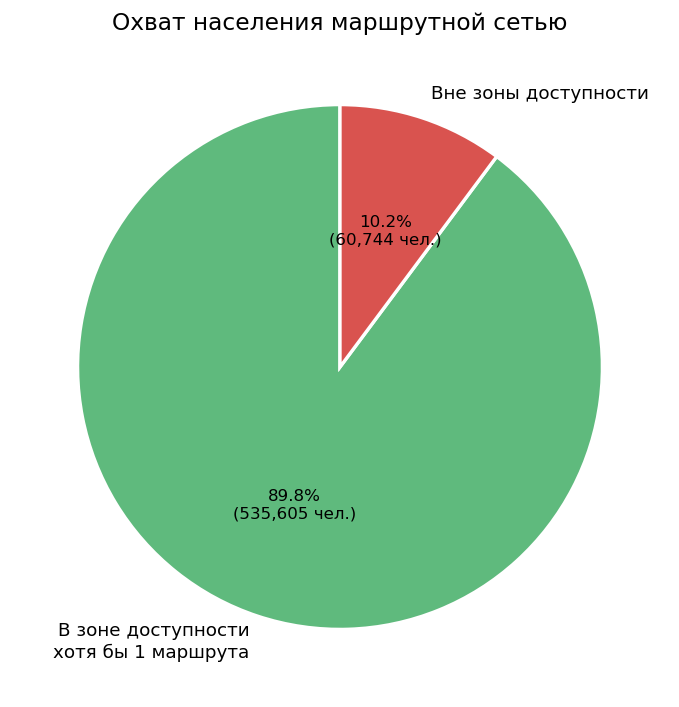

In [55]:
# ============================================================
# ЯЧЕЙКА 9.6 — Сводная «пирог»: охват всеми маршрутами
# ============================================================

served   = total_served_pop
unserved = total_population - total_served_pop

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    [served, unserved],
    labels=["В зоне доступности\nхотя бы 1 маршрута", "Вне зоны доступности"],
    autopct=lambda p: f"{p:.1f}%\n({p / 100 * total_population:,.0f} чел.)",
    colors=["#5fba7d", "#d9534f"],
    startangle=90,
    textprops={"fontsize": 11},
    pctdistance=0.55,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)

for t in autotexts:
    t.set_fontsize(10)

ax.set_title("Охват населения маршрутной сетью", fontsize=14)

plt.tight_layout()
plt.show()

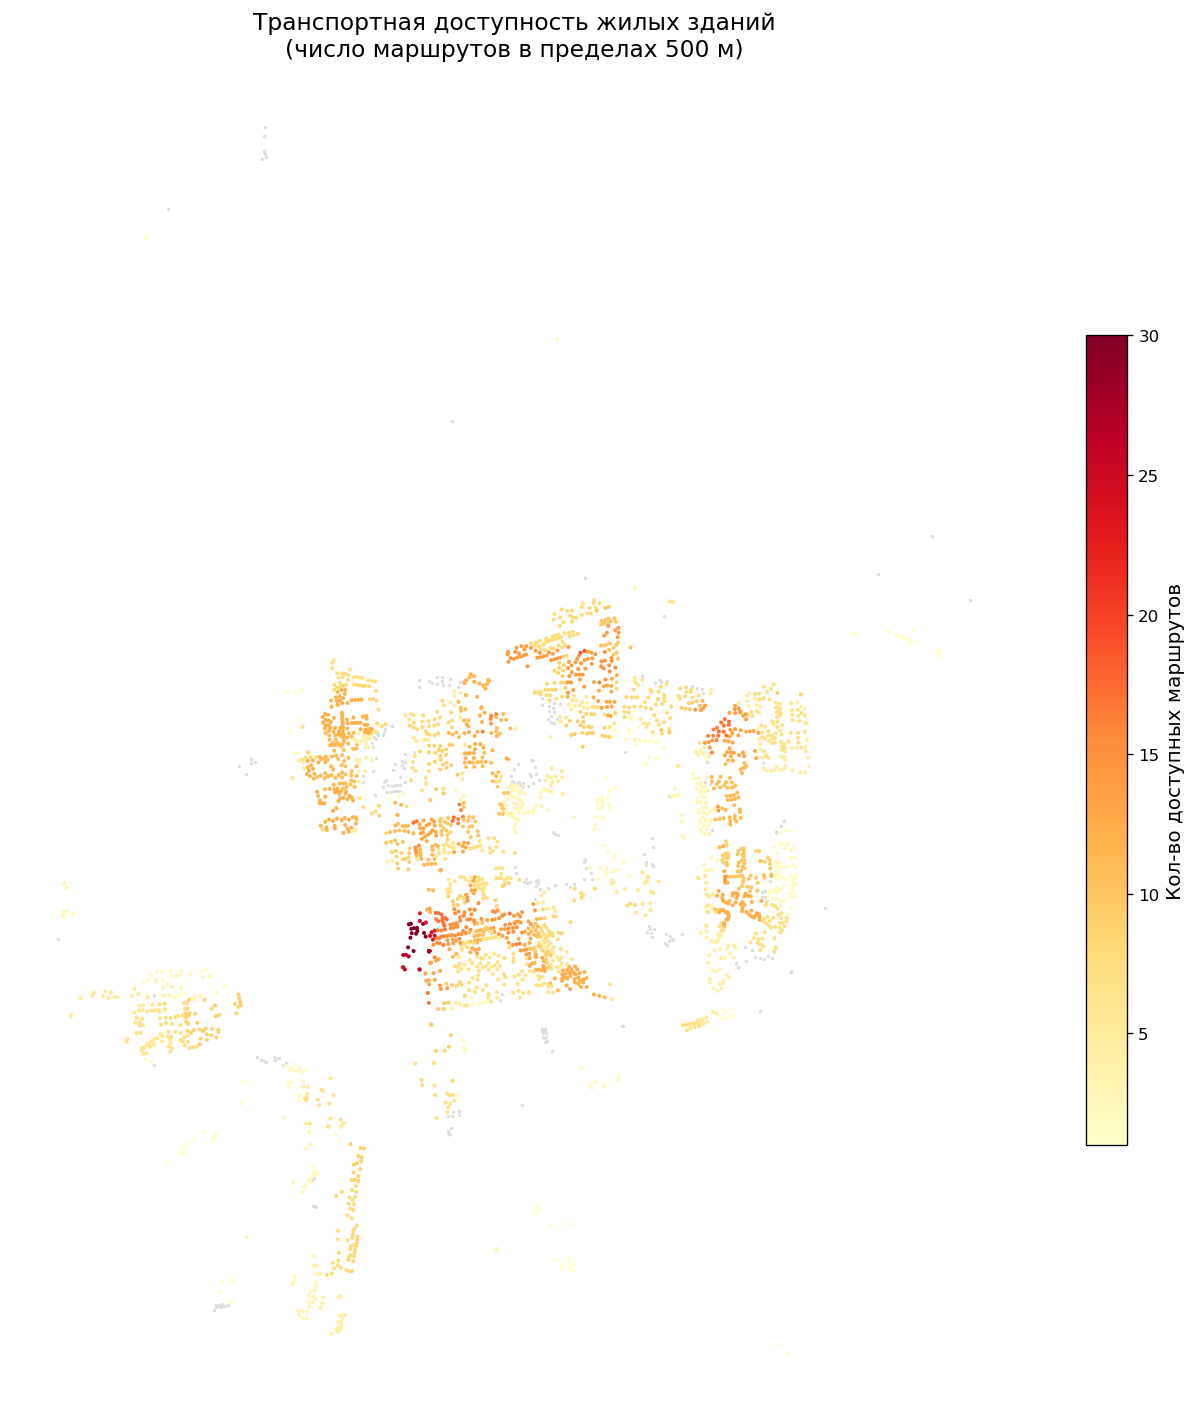

In [56]:
# ============================================================
# ЯЧЕЙКА 9.7 — Картограмма: плотность обслуживания (опционально)
# ============================================================

# Количество маршрутов, доступных жителям каждого здания
routes_per_building = (
    bld_routes_unique
    .groupby("building_id")["ya_line_id"]
    .nunique()
    .reset_index()
    .rename(columns={"ya_line_id": "routes_available"})
)

buildings_map = buildings.merge(routes_per_building, on="building_id", how="left")
buildings_map["routes_available"] = buildings_map["routes_available"].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 12))

# Здания без маршрутов — серым фоном
buildings_map[buildings_map["routes_available"] == 0].plot(
    ax=ax, color="#dddddd", markersize=1, label="Нет маршрутов",
)

# Здания с маршрутами — цветовая шкала
buildings_map[buildings_map["routes_available"] > 0].plot(
    ax=ax,
    column="routes_available",
    cmap="YlOrRd",
    markersize=2,
    legend=True,
    legend_kwds={"label": "Кол-во доступных маршрутов", "shrink": 0.6},
)

ax.set_title("Транспортная доступность жилых зданий\n(число маршрутов в пределах 500 м)", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Сохранение результата

In [40]:
# OUTPUT_PATH = r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\routes/route_coverage.csv"

# route_stats.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
# print(f"Результат сохранён: {OUTPUT_PATH}")

# Если нужен GeoPackage с геометрией маршрутов:
route_stats_geo = routes.merge(route_stats, on="ya_line_id", how="right")
route_stats_geo.to_file(r"X:\00_ЛабГрад_ПО\09_Сотрудники\Глазов Ю.А\izhevsk\routes/route_coverage.gpkg", driver="GPKG")